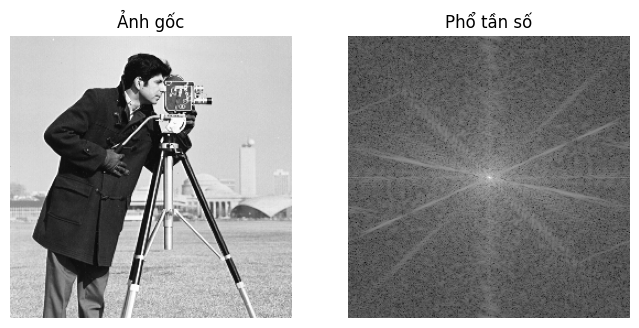

Kích thước ảnh gốc: (256, 256)
Kích thước phổ Fourier: (256, 256)
Giá trị nhỏ nhất của phổ hiển thị: 3.03991224231177
Giá trị lớn nhất của phổ hiển thị: 16.208002257722487
Kiểm tra hoàn tất: Phổ Fourier có cùng kích thước với ảnh đầu vào.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: BIỂU DIỄN ẢNH TRONG MIỀN TẦN SỐ
# Chương/Mục liên quan: Chương 4 - Mục 4.2.1
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách chuyển ảnh từ miền không gian sang miền tần số.
# - Giúp người học quan sát phổ biên độ của ảnh sau biến đổi Fourier.
# - Liên hệ phần code với nội dung lý thuyết về biểu diễn ảnh trong miền tần số.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh gốc trong miền không gian.
# 2. Quan sát được phổ tần số của ảnh sau biến đổi Fourier.
# 3. Hiểu được vai trò của phép dịch tâm phổ tần số để dễ quan sát.

# Input:
# - Dữ liệu đầu vào: ảnh cameraman.png từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh gốc
# - Phổ tần số của ảnh

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"

I = read_gitlab_image(image_uri)

if I is None:
    raise FileNotFoundError("Không tìm thấy file cameraman.png")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

# Ảnh đầu vào sẽ được hiển thị cùng với kết quả ở Mục 5.

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Biến đổi Fourier 2D từ miền không gian sang miền tần số
F = np.fft.fft2(I)

# Dịch thành phần tần số thấp về tâm ảnh để dễ quan sát phổ
F_shift = np.fft.fftshift(F)

# Tính phổ biên độ ở thang log để hiển thị rõ hơn
S = np.log(1 + np.abs(F_shift))

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(S, cmap='gray')
plt.title('Phổ tần số')
plt.axis('off')

plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh gốc:", I.shape)
print("Kích thước phổ Fourier:", F.shape)
print("Giá trị nhỏ nhất của phổ hiển thị:", np.min(S))
print("Giá trị lớn nhất của phổ hiển thị:", np.max(S))

# Kiểm tra kích thước phổ Fourier phải bằng kích thước ảnh gốc
assert I.shape == F.shape, "Sai: Kích thước phổ Fourier không khớp với kích thước ảnh gốc"

print("Kiểm tra hoàn tất: Phổ Fourier có cùng kích thước với ảnh đầu vào.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay ảnh đầu vào bằng một ảnh xám khác để quan sát sự thay đổi của phổ tần số.
# 2. Bỏ dòng np.fft.fftshift(F) và hiển thị np.log(1 + np.abs(F)) để thấy vai trò của phép dịch tâm phổ.
# 3. Thay np.log(1 + np.abs(F_shift)) bằng np.abs(F_shift) để thấy vì sao cần dùng thang log khi hiển thị phổ.